In [1]:
import numpy as np
import torch


seed = 1712
np.random.seed(seed)
torch.manual_seed(seed)

In [2]:
hidden_channels = 64
num_gnn_layers = 3

In [3]:
num_ue = 6
num_ap = 30
num_antenna = 1
tau=20; power_f=0.2; D=1; f=1900; Hb=15; Hm=1.65; d0=0.01;d1=0.05;


noise_p = 10**((-203.975+10*np.log10(20*10**6)+9)/10);
rho_d = power_f/noise_p
rho_p = power_f/noise_p

In [4]:
import numpy as np
import scipy.io
from Utils.data_gen_ldpc import build_cen_loader_ldpc

def build_cen_loaders_for_scenario(
    num_ue,
    num_ap,
    batch_size,
    num_train,
    num_test,
    rho_d,
    seed=2024,
    data_dir='Data'
):
    """
    Tạo train_loader_cen, test_loader_cen cho 1 scenario (num_ue, num_ap)
    dùng đúng logic bạn đã viết.
    """
    file_name = f'dl_data_with_power_1000_{num_ue}_{num_ap}'
    mat_data = scipy.io.loadmat(f'{data_dir}/{file_name}.mat')

    beta_all  = mat_data['betas']
    gamma_all = mat_data['Gammas']
    power_all = mat_data['power'] / rho_d
    phi_all   = mat_data['Phii_cf'].transpose(0, 2, 1)
    opt_rates_all = mat_data['R_cf_opt_min'][0]  # nếu cần dùng để so sánh

    label_all = power_all

    # split train / test
    perm = np.random.RandomState(seed).permutation(beta_all.shape[0])
    train_idx = perm[:num_train]
    test_idx  = perm[num_train: num_train + num_test]

    # Centralized Data
    train_data_cen, train_loader_cen = build_cen_loader_ldpc(
        beta_all[train_idx],
        gamma_all[train_idx],
        label_all[train_idx],
        phi_all[train_idx],
        batch_size,
        isShuffle=True
    )
    test_data_cen, test_loader_cen = build_cen_loader_ldpc(
        beta_all[test_idx],
        gamma_all[test_idx],
        label_all[test_idx],
        phi_all[test_idx],
        batch_size
    )

    return {
        "train_loader": train_loader_cen,
        "test_loader":  test_loader_cen,
        "train_idx":    train_idx,
        "test_idx":     test_idx,
        "opt_rates":    opt_rates_all,  # full; nếu cần theo train/test thì tự slice
    }

In [5]:
import torch
from torch.utils.data import DataLoader, random_split
num_ues = [6, 8, 10]      # ví dụ
num_aps = [30, 40, 50]       # ví dụ

num_rounds = 500
eval_round = num_rounds//10
batch_size = 32
num_train = 800
num_test = 200
num_eval = 500
lr = 5e-3
step_size = num_rounds//10
gamma = 0.8
client_fraction = 0.6
num_epochs = 1000
scenario_configs = []
for ue in num_ues:
    for ap in num_aps:
        scen_name = f"UE{ue}_AP{ap}"
        scen_info = build_cen_loaders_for_scenario(
            num_ue    = ue,
            num_ap    = ap,
            batch_size= batch_size,
            num_train = num_train,
            num_test  = num_test,
            rho_d     = rho_d,      # bạn đã định nghĩa ở ngoài
            seed      = seed,
            data_dir  = 'Data/dl_datasets'
        )
        scenario_configs.append({
            "name": scen_name,
            "num_ue": ue,
            "num_ap": ap,
            "train_loader": scen_info["train_loader"],
            "test_loader":  scen_info["test_loader"],
            "train_idx":    scen_info["train_idx"],
            "test_idx":     scen_info["test_idx"],
            "opt_rates":    scen_info["opt_rates"],
        })

c:\Users\wine\Giang\Code\Viet\new\densityevolution\GNN_FL_cf_mMIMO\Utils\data_gen_ldpc.py:152: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  data.y = torch.tensor([eta_single_all], dtype=torch.float32).to(device)


In [6]:
dim_dict = {
    'VN': 20,
    'CN': 1,
    'edge': 2,
}

metadata = [
    ('VN', 'to', 'CN'),
    ('CN', 'to', 'VN'),
]

In [7]:
from Models.LDPC_new import LDPCPowerGNN
from Utils.MTAdam import MTAdam, rate_constraint_loss_sum, ldpc_train_mtadam_sum, ldpc_eval_mtadam_sum,  beta3_schedule, update_alpha

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Khởi tạo model như bạn đang dùng
model = LDPCPowerGNN(
    vn_dim      = dim_dict['VN'],
    cn_dim      = dim_dict['CN'],
    edge_dim    = dim_dict['edge'],
    message_dim = 64,
    hidden      = 32,
    num_iter    = 3,
    gamma_idx   = 1,
    power_limit = rho_d,
).to(device)

optimizer = MTAdam(
    model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999, 0.9),
    eps=1e-8,
    weight_decay=0.0,
)

In [14]:
alpha_power = 1e-6      # weight cho power constraint
alpha_rate  = 1.0       # nếu bạn có dùng rate_constraint_loss
beta3_lo, beta3_hi = 0.5, 0.9
target_rate = 0.1       # ngưỡng min-rate
num_epochs_cen = 200
gamma_idx = 1
power_limit = 1.0
hist = {
    cfg["name"]: {
        "train_rate": [],
        "test_rate": [],
        "train_p_c": [],
        "test_p_c": [],
        "train_r_c": [],
        "test_r_c": [],
        "train_rate_viol": [],
        "test_rate_viol": [],
    }
    for cfg in scenario_configs
}


In [15]:
# khởi tạo hist theo từng scenario
hist = {
    cfg["name"]: {
        "train_sumrate": [],
        "test_sumrate": [],
        "train_p_c": [],
        "test_p_c": [],
        "train_r_c": [],
        "test_r_c": [],
        "train_rate_viol": [],
        "test_rate_viol": [],
        "train_task_loss": [],
    }
    for cfg in scenario_configs
}

for epoch in range(num_epochs_cen):
    epoch_ratio = epoch / max(1, (2 * num_epochs_cen // 3))

    # === update beta3 (MTAdam betas[2]) ===
    beta3_t = beta3_schedule(
        epoch,
        num_epochs_cen,
        beta3_start=beta3_lo,
        beta3_end=beta3_hi
    )
    for group in optimizer.param_groups:
        beta1, beta2, _ = group["betas"]
        group["betas"] = (beta1, beta2, beta3_t)

    # === train lần lượt trên từng scenario ===
    for cfg in scenario_configs:
        name         = cfg["name"]
        train_loader = cfg["train_loader"]
        test_loader  = cfg["test_loader"]

        # ---- train 1 epoch trên scenario này (max sum-rate) ----
        train_task_loss, train_p_c_loss, train_r_c_loss = ldpc_train_mtadam_sum(
            epochRatio   = epoch_ratio,
            dataLoader   = train_loader,
            model        = model,
            optimizer    = optimizer,
            tau          = tau,
            rho_p        = rho_p,
            rho_d        = rho_d,
            num_antenna  = num_antenna,
            alpha_power  = alpha_power,
            alpha_rate   = alpha_rate,
            beta3        = beta3_t,
            gamma_idx    = gamma_idx,
            power_limit  = power_limit,
            target_rate  = target_rate,
            rate_mode    = 'per_user',   # hoặc 'min' tùy bạn
        )

        # ---- eval trên train set ----
        train_sumrate, train_p_c_eval, train_r_c_eval, train_rate_viol = ldpc_eval_mtadam_sum(
            dataLoader   = train_loader,
            model        = model,
            tau          = tau,
            rho_p        = rho_p,
            rho_d        = rho_d,
            num_antenna  = num_antenna,
            gamma_idx    = gamma_idx,
            power_limit  = power_limit,
            target_rate  = target_rate,
            rate_mode    = 'per_user',
        )

        # ---- eval trên test set ----
        test_sumrate, test_p_c_eval, test_r_c_eval, test_rate_viol = ldpc_eval_mtadam_sum(
            dataLoader   = test_loader,
            model        = model,
            tau          = tau,
            rho_p        = rho_p,
            rho_d        = rho_d,
            num_antenna  = num_antenna,
            gamma_idx    = gamma_idx,
            power_limit  = power_limit,
            target_rate  = target_rate,
            rate_mode    = 'per_user',
        )

        # ---- update alpha_power & alpha_rate ----
        alpha_power = update_alpha(
            alpha_old   = alpha_power,
            c_loss_epoch= train_p_c_loss,
            c_high      = 1e-2,
            c_low       = 1e-4,
            up_factor   = 1.05,
            down_factor = 0.9,
            alpha_min   = 1e-7,
            alpha_max   = 1e-6,
        )

        alpha_rate = update_alpha(
            alpha_old   = alpha_rate,
            c_loss_epoch= train_r_c_loss,
            c_high      = 1e-2,
            c_low       = 1e-4,
            up_factor   = 1.05,
            down_factor = 0.9,
            alpha_min   = 1e-7,
            alpha_max   = 1e-3,   # cho rate có thể lớn hơn chút
        )

        # ---- lưu lịch sử cho từng scenario ----
        hist[name]["train_task_loss"].append(train_task_loss)
        hist[name]["train_sumrate"].append(train_sumrate)
        hist[name]["test_sumrate"].append(test_sumrate)
        hist[name]["train_p_c"].append(train_p_c_eval)
        hist[name]["test_p_c"].append(test_p_c_eval)
        hist[name]["train_r_c"].append(train_r_c_eval)
        hist[name]["test_r_c"].append(test_r_c_eval)
        hist[name]["train_rate_viol"].append(train_rate_viol)
        hist[name]["test_rate_viol"].append(test_rate_viol)

        # ---- log ----
        print(
            f"[{name}] Epoch {epoch+1:03d}/{num_epochs_cen} | "
            f"beta3={beta3_t:.4f} | "
            f"alpha_power={alpha_power:.4e} | "
            f"alpha_rate={alpha_rate:.4e} | "
            f"Train Task Loss={train_task_loss:.4f} | "
            f"Train SumRate={train_sumrate:.4f} | "
            f"Test SumRate={test_sumrate:.4f} | "
            f"Train Power C Loss={train_p_c_eval:.4e} | "
            f"Test Power C Loss={test_p_c_eval:.4e} | "
            f"Train Rate C Loss={train_r_c_eval:.4e} | "
            f"Test Rate C Loss={test_r_c_eval:.4e} | "
            f"Train Rate viol={train_rate_viol*100:.1f}% | "
            f"Test Rate viol={test_rate_viol*100:.1f}%"
        )


[UE6_AP30] Epoch 001/200 | beta3=0.5000 | alpha_power=9.0000e-07 | alpha_rate=1.0000e+00 | Train Task Loss=-6.6247 | Train SumRate=7.4649 | Test SumRate=7.5884 | Train Power C Loss=0.0000e+00 | Test Power C Loss=0.0000e+00 | Train Rate C Loss=4.7407e-05 | Test Rate C Loss=5.4644e-05 | Train Rate viol=1.7% | Test Rate viol=1.5%
[UE6_AP40] Epoch 001/200 | beta3=0.5000 | alpha_power=8.1000e-07 | alpha_rate=9.0000e-01 | Train Task Loss=-8.3283 | Train SumRate=8.3710 | Test SumRate=8.4926 | Train Power C Loss=0.0000e+00 | Test Power C Loss=0.0000e+00 | Train Rate C Loss=4.9478e-05 | Test Rate C Loss=2.2900e-05 | Train Rate viol=1.4% | Test Rate viol=1.1%
[UE6_AP50] Epoch 001/200 | beta3=0.5000 | alpha_power=7.2900e-07 | alpha_rate=8.1000e-01 | Train Task Loss=-9.1974 | Train SumRate=9.5935 | Test SumRate=9.6615 | Train Power C Loss=0.0000e+00 | Test Power C Loss=0.0000e+00 | Train Rate C Loss=7.3758e-06 | Test Rate C Loss=1.6751e-05 | Train Rate viol=0.3% | Test Rate viol=0.5%
[UE8_AP30] Ep

# Results

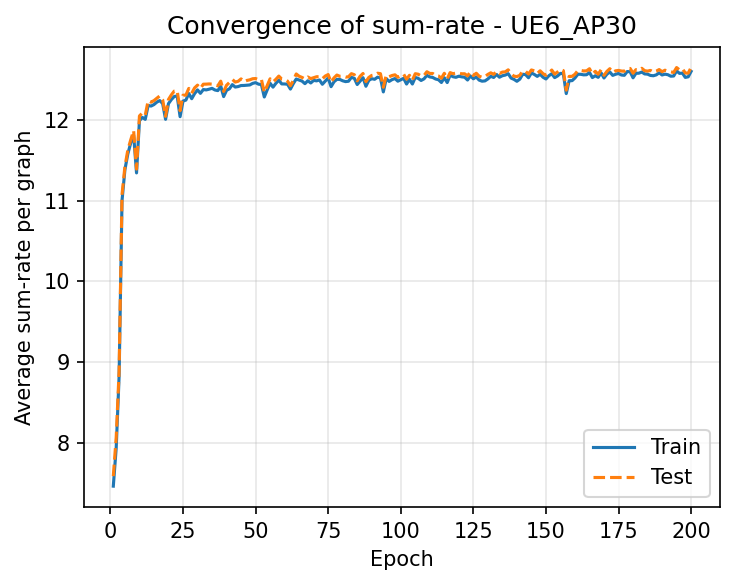

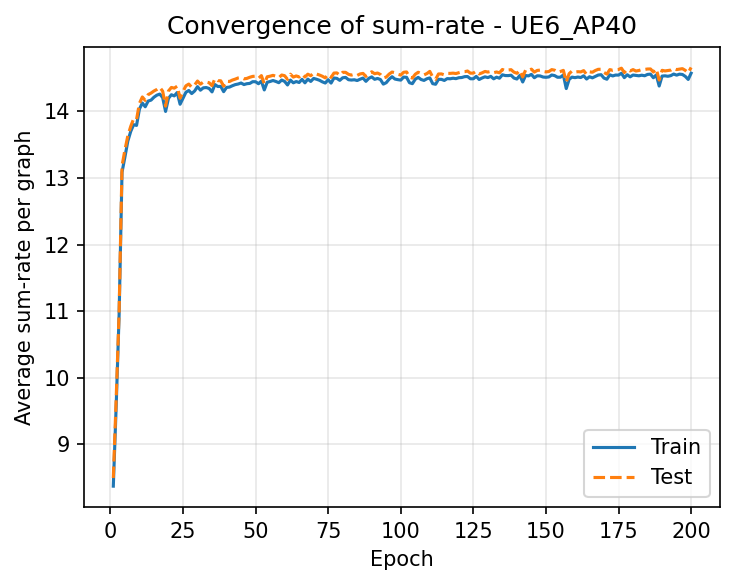

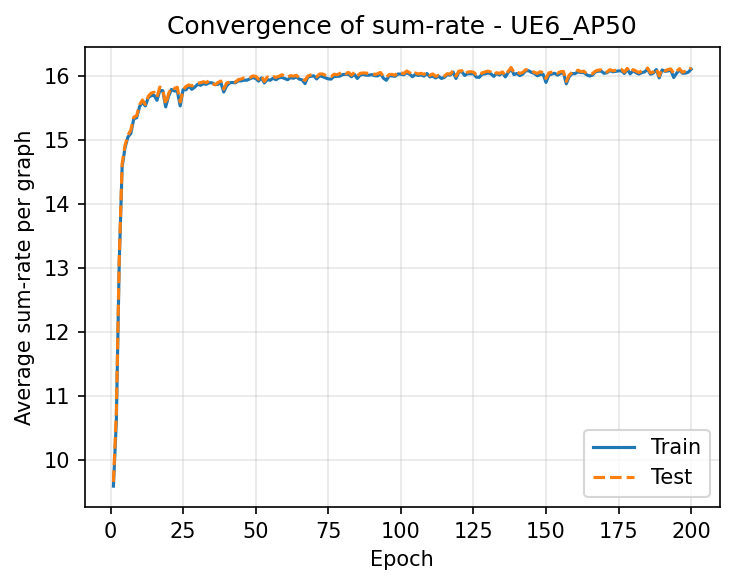

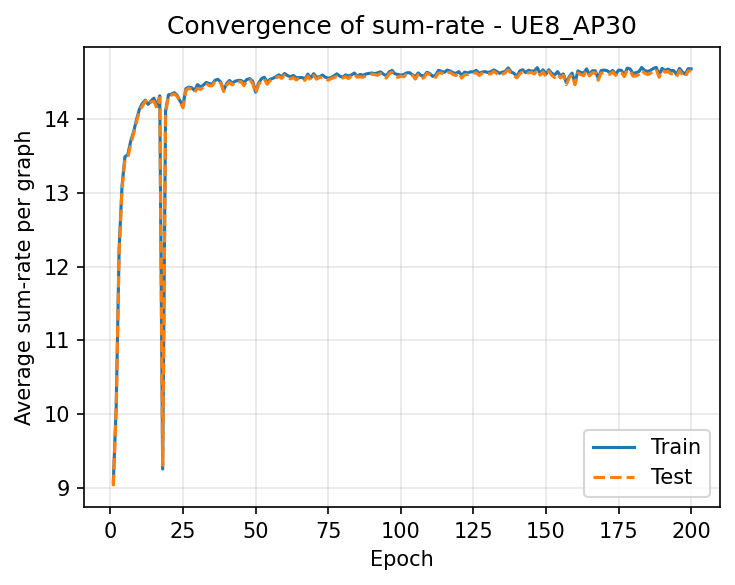

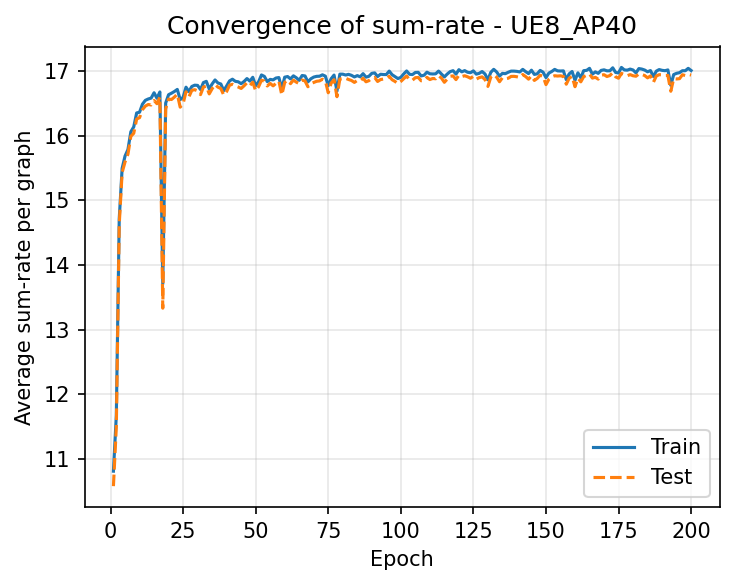

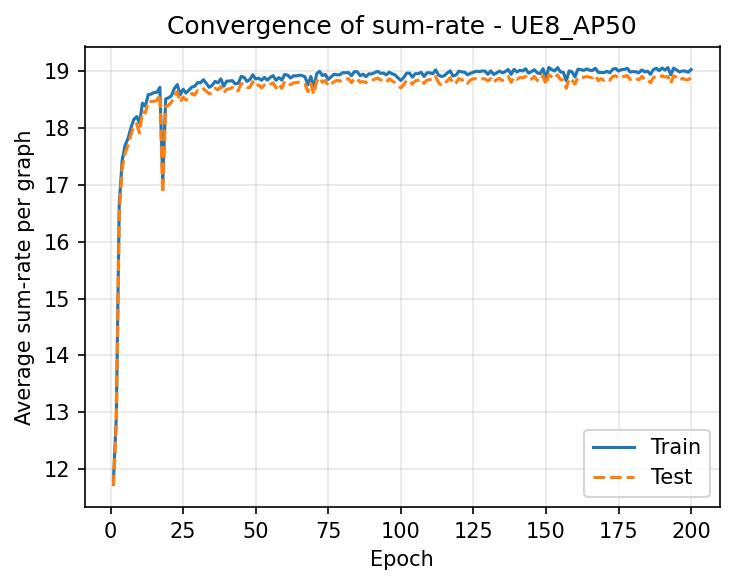

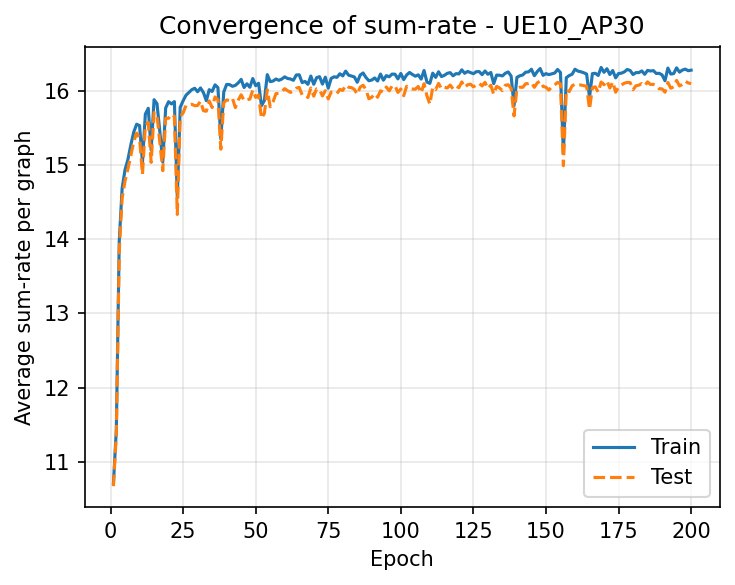

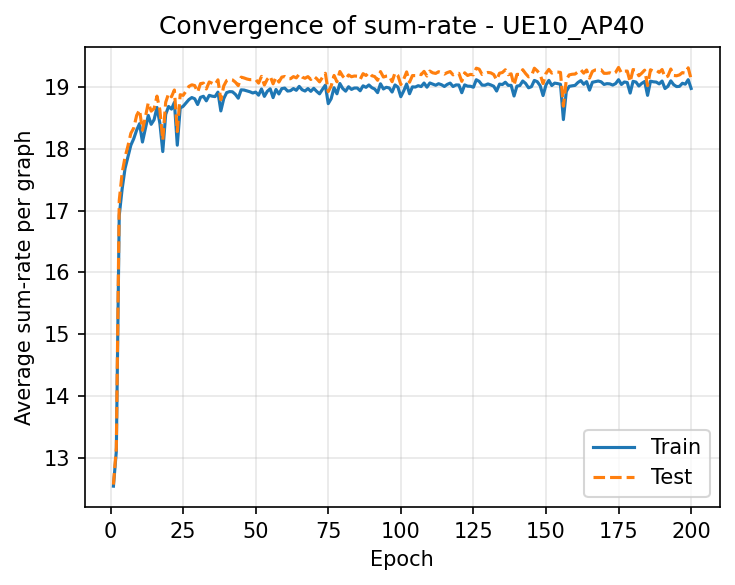

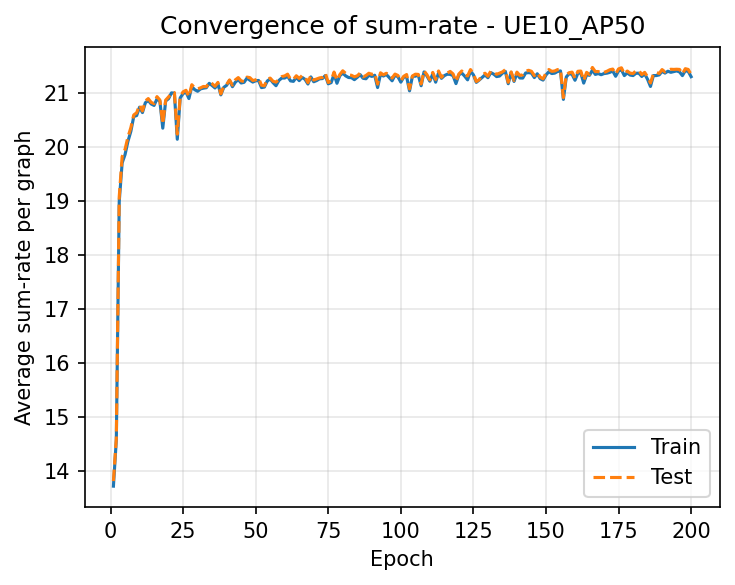

In [19]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, num_epochs_cen + 1)
scenario_names = [cfg["name"] for cfg in scenario_configs]

for name in scenario_names:
    plt.figure(figsize=(5, 4), dpi=150)
    plt.plot(epochs, hist[name]["train_sumrate"], label="Train")
    plt.plot(epochs, hist[name]["test_sumrate"],  label="Test", linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("Average sum-rate per graph")
    plt.title(f"Convergence of sum-rate - {name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


C:\Users\wine\AppData\Local\Temp\ipykernel_44024\1429617769.py:10: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


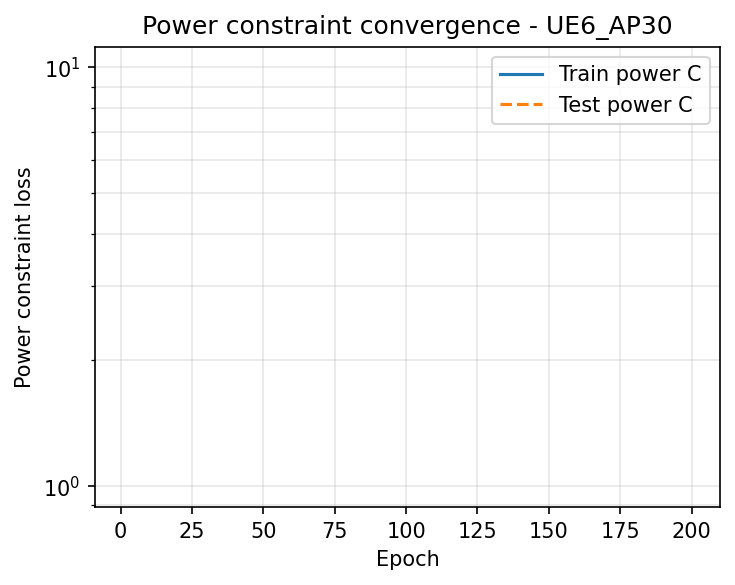

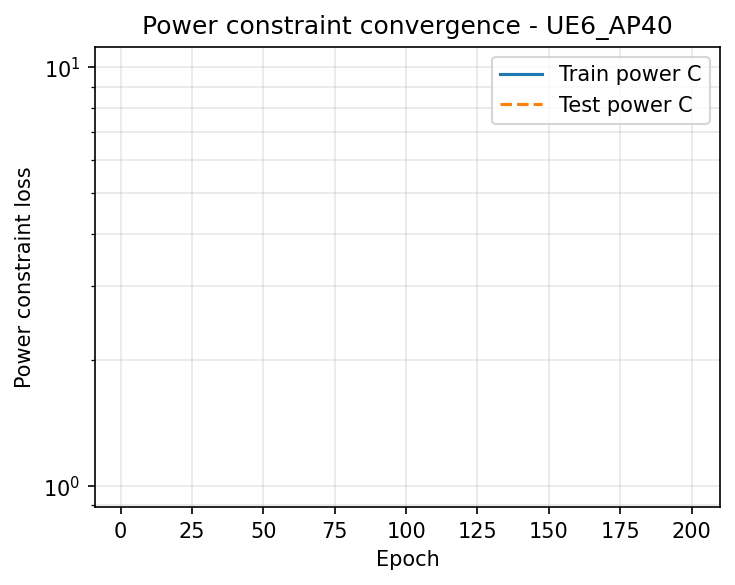

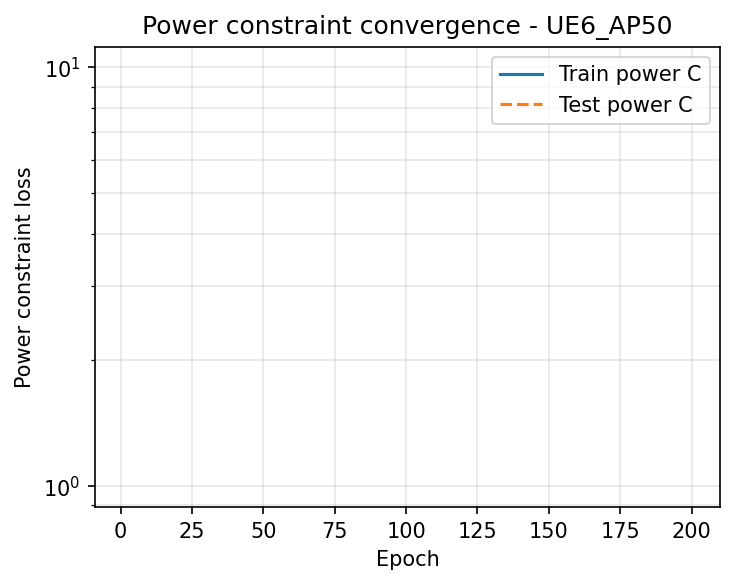

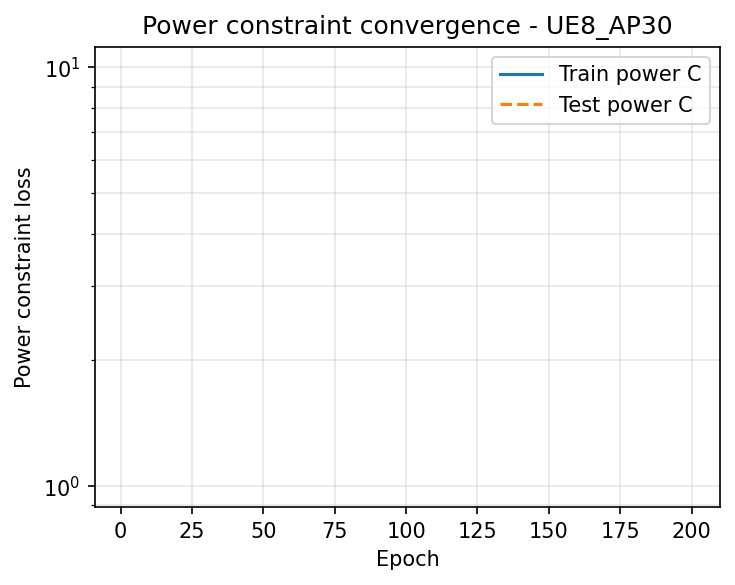

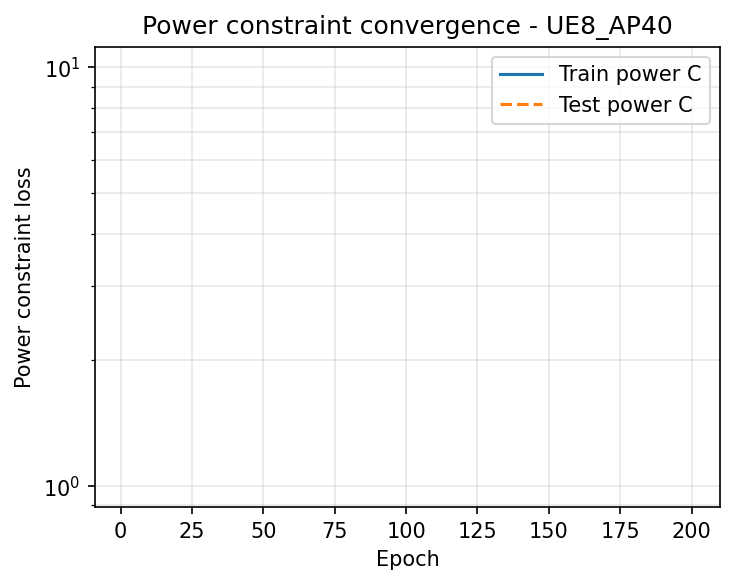

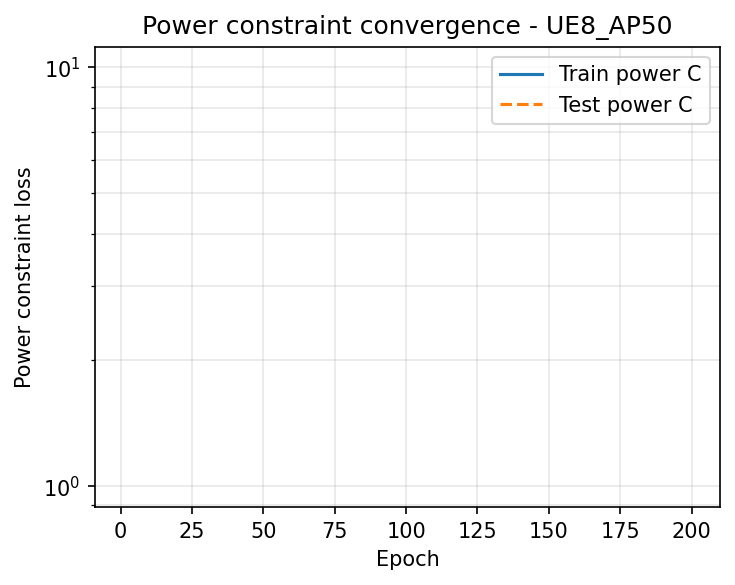

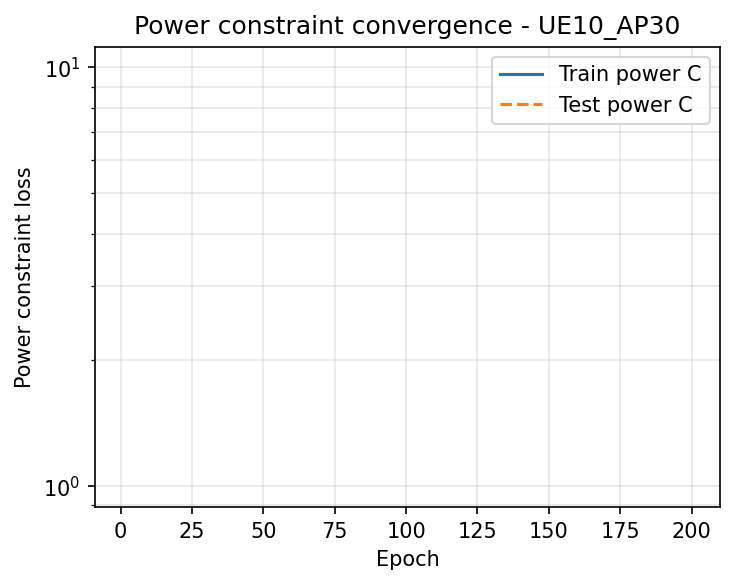

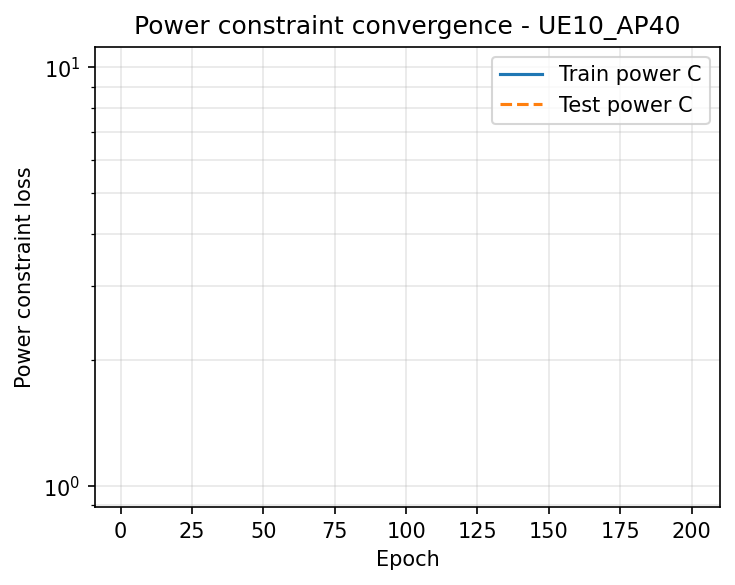

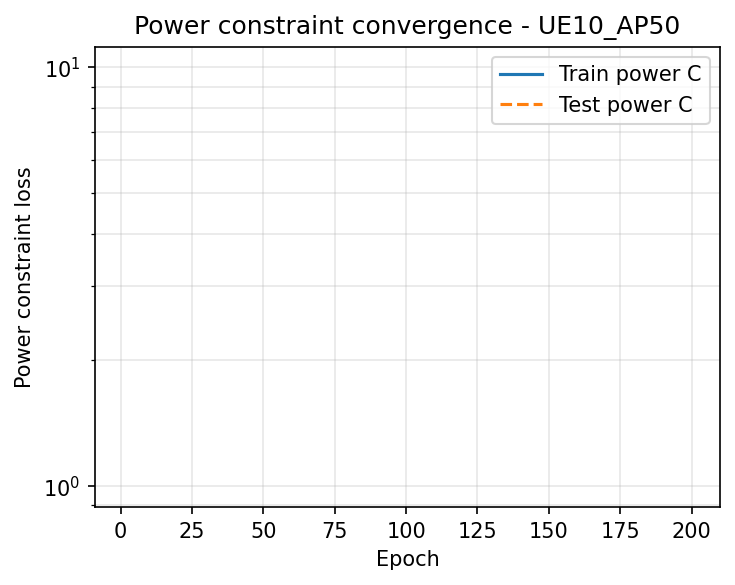

In [20]:
for name in scenario_names:
    plt.figure(figsize=(5, 4), dpi=150)
    plt.semilogy(epochs, hist[name]["train_p_c"], label="Train power C")
    plt.semilogy(epochs, hist[name]["test_p_c"],  label="Test power C", linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("Power constraint loss")
    plt.title(f"Power constraint convergence - {name}")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


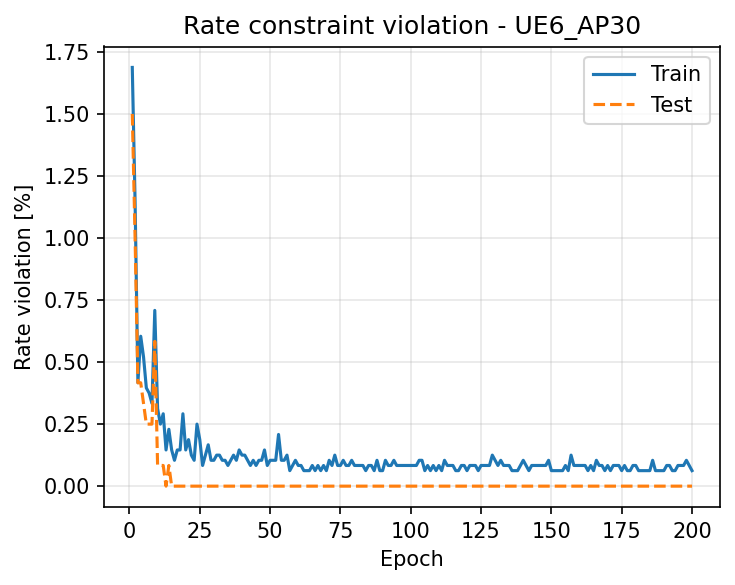

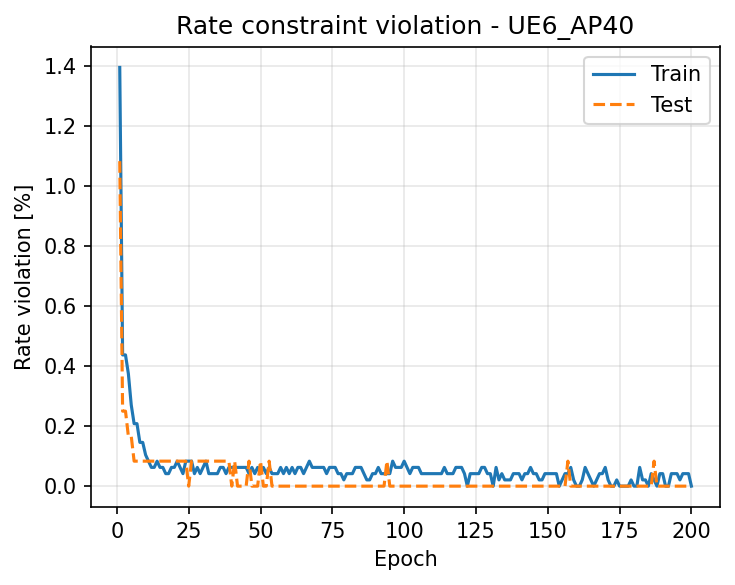

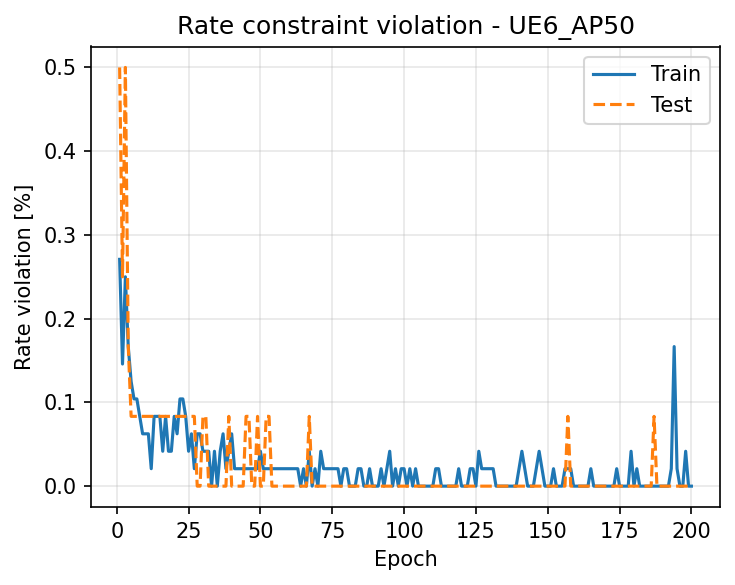

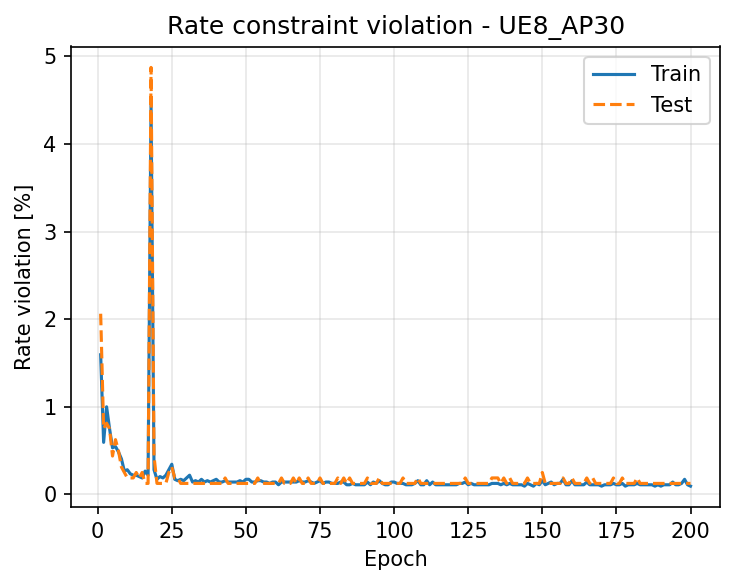

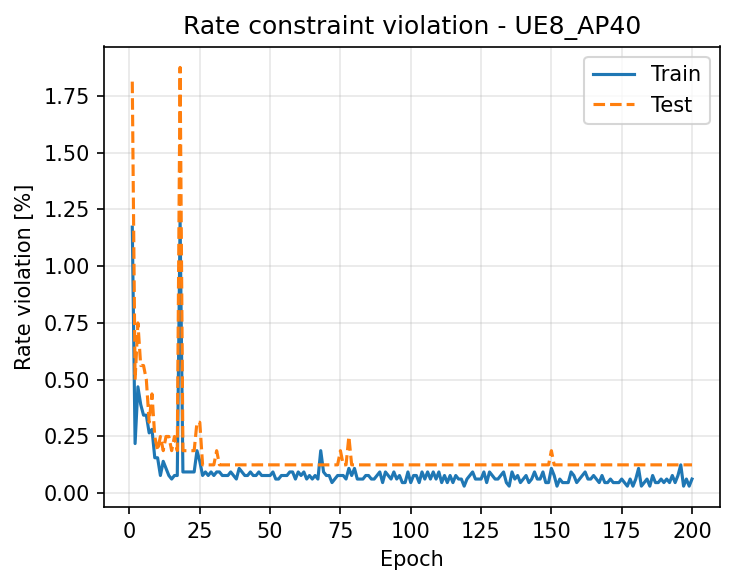

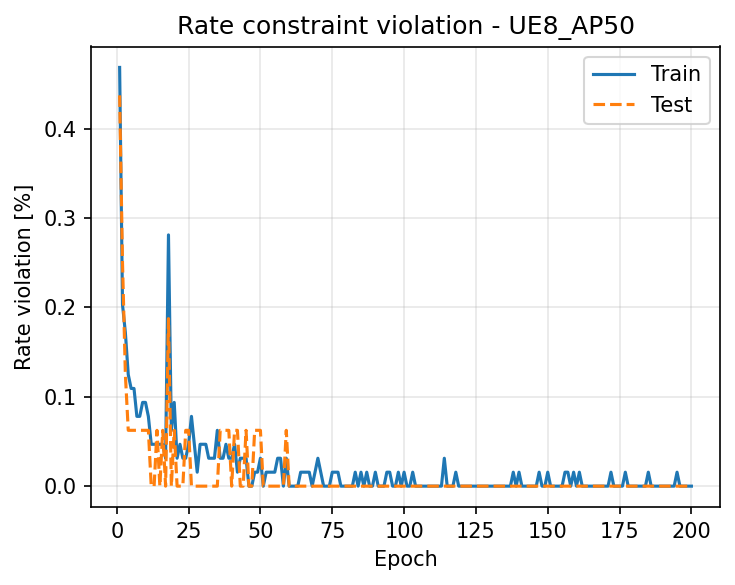

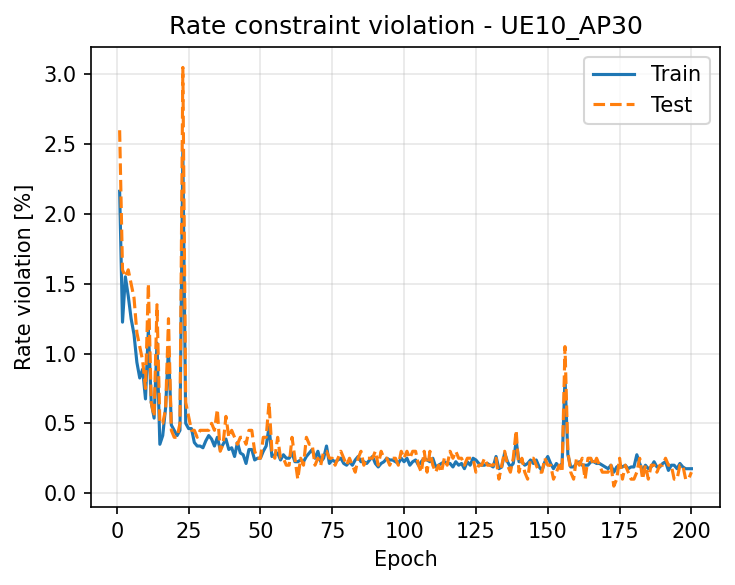

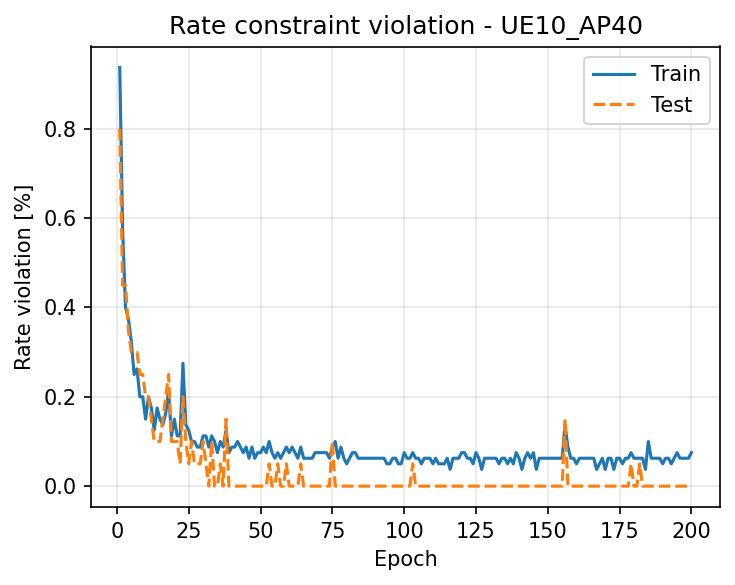

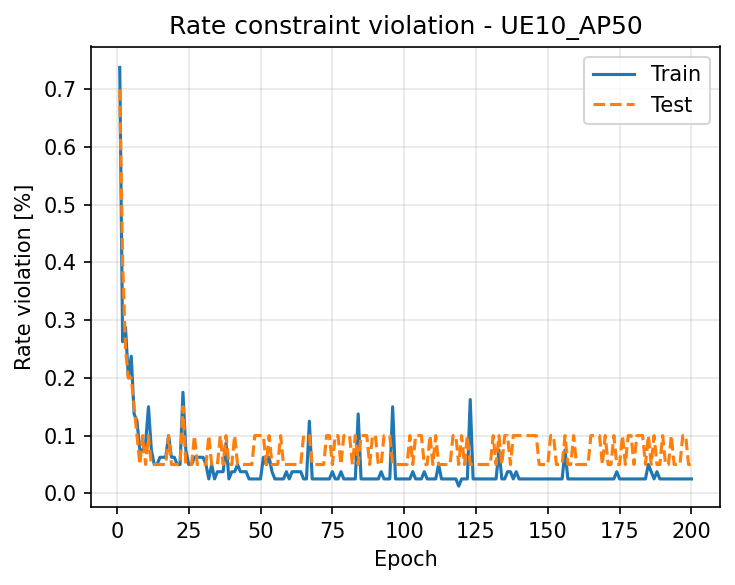

In [21]:
for name in scenario_names:
    plt.figure(figsize=(5, 4), dpi=150)
    plt.plot(epochs, np.array(hist[name]["train_rate_viol"]) * 100, label="Train")
    plt.plot(epochs, np.array(hist[name]["test_rate_viol"])  * 100, label="Test", linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("Rate violation [%]")
    plt.title(f"Rate constraint violation - {name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
